# Diffusion models of $\mu$-CHP adoption

In [1]:
import os
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from phdtools import DATA_DIR, RESULTS_DIR
from phdtools.rdm import DataID, DataType, Chapter, auto_create_path, write_metadata

TODAY = datetime.today().strftime("%y%m%d")
FILE_DATE = os.getenv("FILE_DATE", "260407")

overwrite = False
if overwrite:
    FILE_DATE = TODAY

## Empirical Data

Data taken from Market master data register (Markstammdatenregister, MaStR). The MaStR is managed by the Federal Network Agency (Bundesnetzagentur, BNetzA). 
> The Market Master Data Register is the register for the German electricity and gas market. It is abbreviated to MaStR. The MaStR primarily registers master data on electricity and gas generation plants. The master data of market players such as system operators, grid operators and energy suppliers must also be registered. 

Data from past queries is stored on a Windows shared drive: `\\FST-218.fst.maschinenbau.tu-darmstadt.de\Common\Meck\231219_Daten_Diss`. 

On Linux systems make sure `\\FST-218.fst.maschinenbau.tu-darmstadt.de\Common` is mounted! 
To get the IP adress `ping FST-218` in your Windows `cmd` (IP adress is `192.168.101.218`). 
In WSL you can mount with DrvFS. Use Samba (cifs) when using native Linux systems or others VMs. 

```shell
sudo mkdir /mnt/common
sudo mount -t drvfs '\\192.168.101.218\Common' /mnt/common
```

In [2]:
# DATA_DIR = Path(r"/mnt/common/Meck/231219_Daten_Diss")

In [3]:
!ls {DATA_DIR / "bafa-mastr"}

data_250527_MaStR_FuelCells_NaturalGas_50kW.csv
data_250527_MaStR_FuelCells_NaturalGas.csv
data_250527_MaStR_FuelCells.csv
Metadata


In [4]:
mastr = pd.read_csv(
    DATA_DIR / "bafa-mastr" / "data_250527_MaStR_FuelCells_NaturalGas.csv",
    sep=";",
    decimal=",",
)
mask = ~mastr.loc[:, "Inbetriebnahmedatum der Einheit"].isna()
mastr = mastr[mask]
mastr.head()

,MaStR-Nr. der Einheit,Anzeige-Name der Einheit,Betriebs-Status,Energieträger,Bruttoleistung der Einheit,Nettonennleistung der Einheit,Inbetriebnahmedatum der Einheit,Registrierungsdatum der Einheit,Bundesland,Postleitzahl,...,MaStR-Nr. der Lokation,MaStR-Nr. der EEG-Anlage,EEG-Anlagenschlüssel,Inbetriebnahmedatum der EEG-Anlage,Installierte Leistung der EEG-Anlage,Zuschlagnummer (EEG/KWK-Ausschreibung),MaStR-Nr. der KWK-Anlage,Inbetriebnahmedatum der KWK-Anlage,Elektrische KWK-Leistung,Thermische Nutzleistung in kW
0,SEE922004018945,Brennzelle,In Betrieb,Erdgas,0.750,0.75,02/11/2018,24/12/2020,Thüringen,36460,...,SEL930527901606,NaN,NaN,NaN,NaN,NaN,KWK931759627050,02/11/2018,1.00,1.162
1,SEE902214962610,Blockkraftheizwerk,In Betrieb,Erdgas,0.750,0.75,20/11/2018,31/01/2019,Nordrhein-Westfalen,53783,...,SEL954361024673,NaN,NaN,NaN,NaN,NaN,KWK956812340608,31/01/2019,0.75,3500.000
2,SEE913200238916,VD-Power,In Betrieb,Erdgas,0.750,0.75,07/11/2018,11/02/2019,Nordrhein-Westfalen,53844,...,SEL946626945335,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SEE975684047095,BG15,In Betrieb,Erdgas,1.500,1.50,10/07/2018,31/01/2019,Niedersachsen,31840,...,SEL909495544818,NaN,NaN,NaN,NaN,NaN,KWK965011506630,10/07/2018,1.50,1.200
4,SEE916218219809,Vitovalor PT2 Tassiloweg 5,In Betrieb,Erdgas,0.755,0.75,01/11/2018,01/02/2019,Bayern,82319,...,SEL959226505434,NaN,NaN,NaN,NaN,NaN,KWK942904565035,11/11/2018,0.75,1.165


### Binned data (Thesis figure 3.1)

In [5]:
quarter_bins = []
for year in np.arange(2000, 2026):
    quarters = [
        datetime(day=1, month=1, year=year),
        datetime(day=1, month=4, year=year),
        datetime(day=1, month=7, year=year),
        datetime(day=1, month=10, year=year),
    ]
    for the_bin in quarters:
        quarter_bins.append(the_bin)

bins = np.array(quarter_bins, "M8")
bins = bins[:-3]

In [6]:
hist, bin_edges = np.histogram(
    pd.to_datetime(mastr["Inbetriebnahmedatum der Einheit"], format="%d/%m/%Y"),
    bins=bins,
)

In [7]:
data_id = DataID(DataType.FIGURE, Chapter.METHODS, 1)


@auto_create_path
def save_binned_data(path):

    description = (
        "Fuel cells commissioned in Germany between 01.01.2000 and 31.12.2024.\n"
        "Data obtained from the German Network Agency (2025)\n"
        "\n"
        "References:\n"
        "-----------\n"
        "German Network Agency (2025) Marktdatenstammregister. Available at: \n"
        "https://www.marktstammdatenregister.de/MaStR/Einheit/Einheiten/OeffentlicheEinheitenuebersicht#gasverbrauch."
    )

    csv_header = "date,rate,cumulative\n"
    csv_rows = [
        f"{np.datetime64(i,'D')},{j},{k}"
        for i, j, k in zip(bin_edges[1:], hist, np.cumsum(hist))
    ]
    csv_text = "\n".join(csv_rows)

    fname = path / f"{TODAY}_MaStr_FuelCells_binned.csv"

    with open(fname, "w+") as f:
        write_metadata(f, description=description)
        f.write(csv_header)
        f.write(csv_text)


save_binned_data(
    data_id,
    doc=r"Fuel cells commissioned in Germany between 01.01.2000 and 31.12.2024 \autocite{BNetzA.2025a}.",
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools-dev/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/fG9gW1' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [8]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 1).get_path(fail_exists=False)}

260407_MaStr_FuelCells_binned.csv


### Visualize

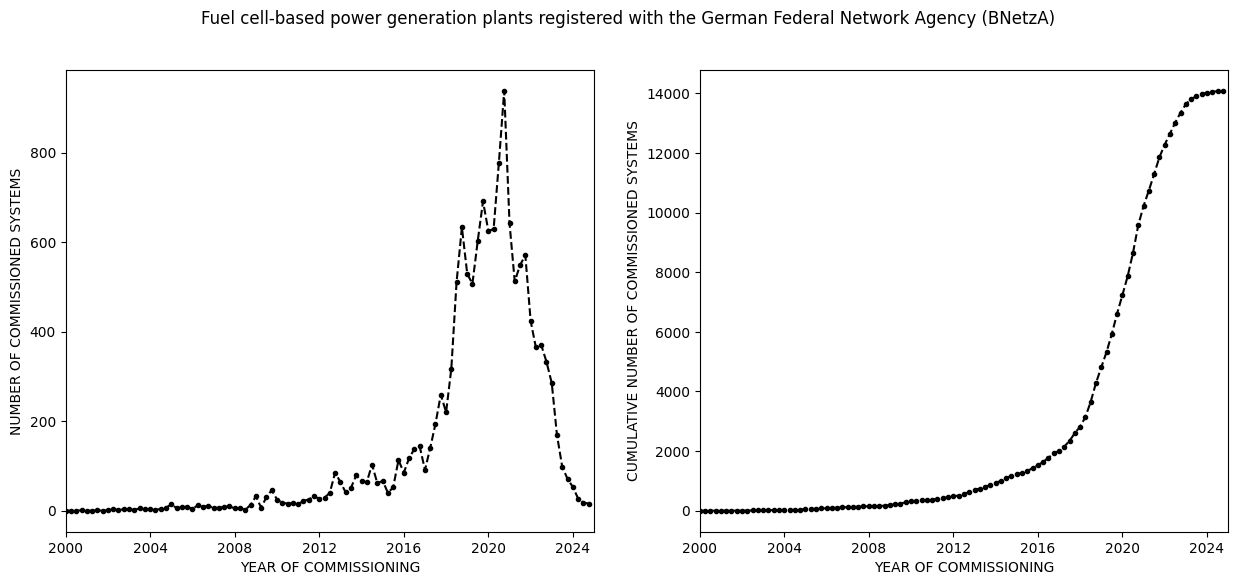

In [9]:
import phdtools.plots

fig, axs = plt.subplots(1, 2, figsize=(10 / 4 * 6, 6))

xmin, xmax = datetime(day=1, month=1, year=2000), datetime(day=1, month=1, year=2025)

axs[0].plot(bin_edges[:-1], hist, linestyle="dashed", marker=".", label="MaStR")
axs[1].plot(
    bin_edges[:-1],
    np.cumsum(hist),
    linestyle="dashed",
    marker=".",
    label="MaStR",
)

for ax in axs:
    _ = ax.set_xlim(xmin, xmax)
    # box_off(ax)

_ = fig.suptitle(
    "Fuel cell-based power generation plants registered with the German Federal Network Agency (BNetzA)"
)

_ = axs[0].set_xlabel("YEAR OF COMMISSIONING")
_ = axs[0].set_ylabel("NUMBER OF COMMISSIONED SYSTEMS")

_ = axs[1].set_xlabel("YEAR OF COMMISSIONING")
_ = axs[1].set_ylabel("CUMULATIVE NUMBER OF COMMISSIONED SYSTEMS")

## Bass Diffusion Model
Bass, F. M. (1969). A New Product Growth for Model Consumer Durables. Management Science, 15(5), 215–227. http://www.jstor.org/stable/2628128

* Total sales comprise initial purchases and replacement purchases. The model is concerned with initial purchases only
* The model identifies two groups of customer: innovators and imitators. For innovators "the pressure of adoption does not increase with the growth of the adoption process". 
* "The probability that an initial purchase will be made at $T$ given that no purchase has yet been made is a linear function of the number of previous buyers" $P(T) = p + q/m Y(T)$ --> really he defines the hazard function -> instantanious rate 

#### Ordinary Least Squares Regression (OLS) as suggested by Bass 1969

$$
\newcommand{\Sales}{S}
\newcommand{\Time}{t}
\newcommand{\CoefOfInnovation}{p}
\newcommand{\CoefOfImtiation}{q}
\newcommand{\TotalInitialPurchases}{m}
\newcommand{\NumPreviousBuyers}{Y}
%
\begin{aligned}
    \Sales(\Time) = \CoefOfInnovation\,\TotalInitialPurchases + 
        (\CoefOfImtiation - \CoefOfInnovation) \NumPreviousBuyers(\Time) -
        \CoefOfImtiation/\TotalInitialPurchases \, \NumPreviousBuyers(\Time)^2 \rightarrow
    \Sales_T = \underbrace{\CoefOfInnovation\,\TotalInitialPurchases}_{a} + 
        \underbrace{(\CoefOfImtiation - \CoefOfInnovation)}_{b} \NumPreviousBuyers_{T-1} -
        \underbrace{\CoefOfImtiation/\TotalInitialPurchases}_{-c} \, \NumPreviousBuyers_{T-1}^2 
\end{aligned}
$$

In [10]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 1).get_path(fail_exists=False)}

260407_MaStr_FuelCells_binned.csv


In [11]:
sales_at_t = (
    pd.read_csv(
        DataID(DataType.FIGURE, Chapter.METHODS, 1).get_path(fail_exists=False)
        / f"{FILE_DATE}_MaStr_FuelCells_binned.csv",
        comment="#",
    )
    .iloc[:, 1]
    .to_numpy()
)

In [12]:
from sklearn.linear_model import LinearRegression

T0 = 60
cum_sales_through_t_minus_one = np.array([0, *np.cumsum(sales_at_t[T0:])[:-1]])

X_train = np.c_[cum_sales_through_t_minus_one, cum_sales_through_t_minus_one**2]
Y_train = sales_at_t[T0:]

reg = LinearRegression(fit_intercept=True)
reg.fit(X_train, Y_train)
a = reg.intercept_
b, c = reg.coef_

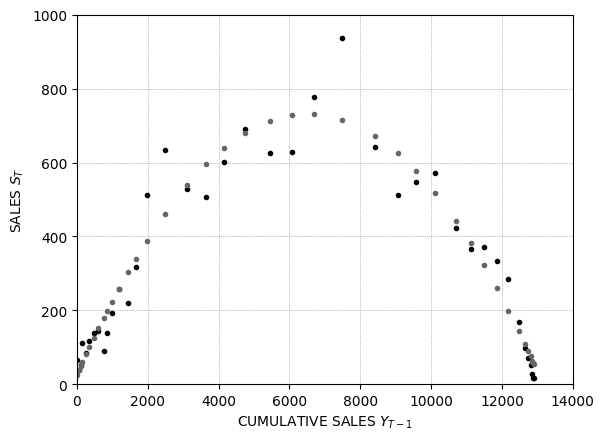

In [13]:
fig, axs = plt.subplots(1, 1)

_ = axs.plot(X_train[:, 0], Y_train, ".")

Y_model = lambda y: a + b * y + c * y**2
_ = axs.plot(X_train[:, 0], Y_model(X_train[:, 0]), ".")

_ = axs.set_xlabel(r"CUMULATIVE SALES $Y_{T-1}$")
_ = axs.set_ylabel(r"SALES $S_T$")

_ = axs.set_xlim(0, 14000)
_ = axs.set_ylim(0, 1000)
_ = axs.grid(True)

In [14]:
print(f"The regression coefficients are: a = {a:.2e}; b = {b:.2e}; c = {c:.2e}")

The regression coefficients are: a = 2.55e+01; b = 2.17e-01; c = -1.66e-05


In [15]:
root = (-b + np.array([1, -1]) * np.sqrt((b**2 - 4 * c * a))) / (2 * c)
print(root)
idx = np.argwhere(root > 0)[0][0]
m = root[idx]

[ -116.9054521  13159.99404999]


In [16]:
p = a / m
q = -m * c

print(m, p, q)

13159.994049993767 0.00194106147512715 0.2185044153623773


In [17]:
F = lambda T: (1 - np.exp(-(p + q) * T)) / (q / p * np.exp(-(p + q) * T) + 1)
f = lambda T: (((p + q) ** 2) / p) * (
    np.exp(-(p + q) * T) / (q / p * np.exp(-(p + q) * T) + 1) ** 2
)

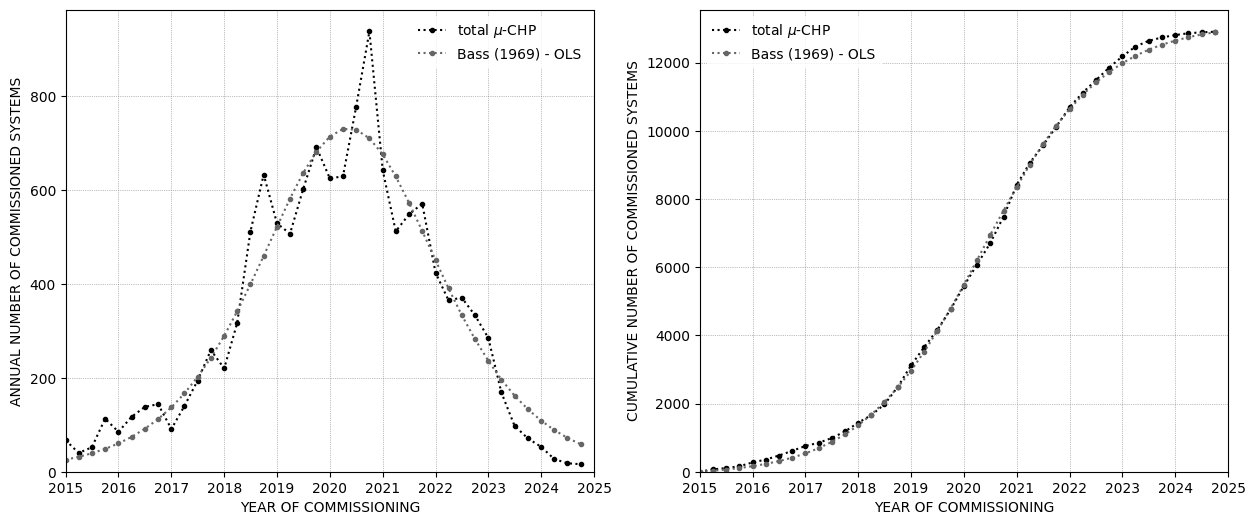

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10 / 4 * 6, 6))
ax = fig.gca()

t = np.arange(0, len(Y_train))

style = {"linestyle": "dotted", "marker": "."}

_ = axs[0].plot(bins[T0:-1], Y_train, label=r"total $\mu$-CHP", **style)
_ = axs[1].plot(bins[T0:-1], X_train[:, 0], label=r"total $\mu$-CHP", **style)

_ = axs[0].plot(bins[T0:-1], m * f(t), label=r"Bass (1969) - OLS", **style)

_ = axs[1].plot(bins[T0:-1], m * F(t), label=r"Bass (1969) - OLS", **style)

_ = axs[0].set_xlabel(r"YEAR OF COMMISSIONING")
_ = axs[0].set_ylabel(r"ANNUAL NUMBER OF COMMISSIONED SYSTEMS")

_ = axs[1].set_xlabel(r"YEAR OF COMMISSIONING")
_ = axs[1].set_ylabel(r"CUMULATIVE NUMBER OF COMMISSIONED SYSTEMS")

for ax in axs:
    # box_off(ax)
    _ = ax.legend()
    _ = ax.grid()
    _ = ax.set_xlim(bins[T0], bins[-1])
    _ = ax.set_ylim(
        0,
    )
    # plt.savefig("Bass1969.svg")

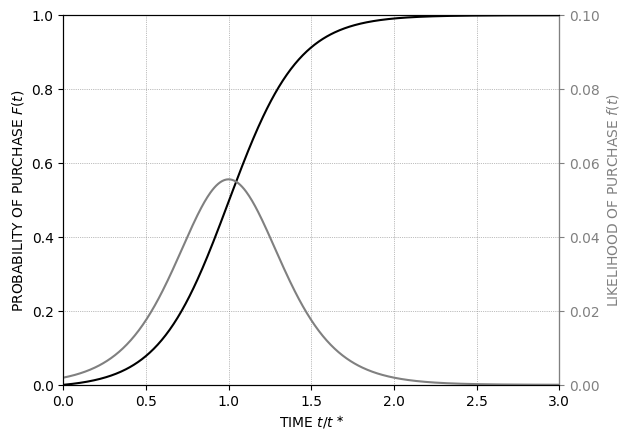

In [19]:
t_star = -1 / (p + q) * np.log(p / q)
s_star = m * (p + q) ** 2 / (4 * q)

t = np.linspace(0, 3, 500)

fig = plt.figure()
ax1 = fig.gca()
ax2 = ax1.twinx()

_ = ax1.plot(t, F(t * t_star), "black")
_ = ax2.plot(t, f(t * t_star), "gray")

_ = ax1.set_xlabel(r"TIME $t/t^\ast$")
_ = ax1.set_ylabel(r"PROBABILITY OF PURCHASE $F(t)$")
_ = ax2.set_ylabel(r"LIKELIHOOD OF PURCHASE $f(t)$", color="gray")

ax2.tick_params(axis="y", colors="gray")
ax2.spines["right"].set_color("gray")

ax1.set_xlim(0, 3)
ax1.set_ylim(0, 1)
ax2.set_ylim(0, 0.1)
ax1.grid(True)

## Faber, Valente and Janssen (2010)

Faber, Albert; Valente, Marco; Janssen, Peter (2010): Exploring domestic micro-cogeneration in the Netherlands: An agent-based demand model for technology diffusion. In Energy Policy 38 (6), pp. 2763–2775. DOI: 10.1016/j.enpol.2010.01.008.

* the authors simulate micro-CHP diffusion for the dutch market
* agents scan the market for available options, visibility of a technology depends on previous knowledge and market share. Visibility of product~$j$ is $$V_j(t) = \max\{V_j(t-1); \min\{A_j+ms_j(t-1)^{\sigma_j};1\}\},$$ where $A_j$ is an advertising factor, $ms_j(t-1)$ is the market share in the previous time step and $\sigma_j$ is a parameter estimating the confidence in the market. 
* agents choose between mirco-CHP and condensing boilers to replace their heating system at the end of its lifetime using present value total cost over a given projection horizon as their sole evaluation criterium
* agent types comprise 5 different categories reflecting different housing situations each corresponding to a separate gas demand per year for heating 
* purchase price is assumed to scale with cumulated sales. Hence, according to Wright's law $$P_j = P_j(t=0)\,X_j(t)^{\log_2({PR})},$$ where $X_j$ is the $X$-th unit of production of product $j$ and $PR$ is the progress ratio. 
* heat-to-power ratio scales with cumulated sales over time
$HPR_t = HPR_{LO} + \frac{HPR_{UP} - HPR_{LO}}{1 + \exp{\{-\beta(t-TLF)\}}}$

In [20]:
!ls {DATA_DIR / "faber-valente-janssen-2010"}

data_faber.yml


In [21]:
# !mpirun -n=8 python3 -m phdtools.models.faber_valente_janssen_2010 {DATA_DIR / "faber-valente-janssen-2010" / "data_faber.yml"}

In [22]:
# !ls ./output

In [23]:
if False:
    out_dir = Path("./output/")
    diffusion_log = out_dir / "adoptions.csv"

    price_log = out_dir / "price.csv"
    heat_to_power_log = out_dir / "heat_to_power_ratio.csv"
    usage_cost_log = out_dir / "usage_cost.csv"
    total_cost_log = out_dir / "total_cost.csv"

    faber = pd.read_csv(diffusion_log)

    price = pd.read_csv(price_log)
    heat_to_power_ratio = pd.read_csv(heat_to_power_log)
    usage_cost = pd.read_csv(usage_cost_log)
    total_cost = pd.read_csv(total_cost_log)

    faber.head()

In [24]:
def diffusion_plot(df: pd.DataFrame, axs=None, **kwargs) -> None:
    """plots simulation results on diffusion data

    Args:
        df: pandas.Dataframe, use pandas.read_csv('log_file')
        axs: matplotlib.pyplot.axes, axes handle
        kwargs: key-word arguments passed to matplotlib plot
    Returns:

    """
    market_size = sum(df.iloc[0, 3:])

    if axs is None:
        fig, axs = plt.subplots(1, 2, figsize=(10 / 4 * 6, 6))

        _ = axs[0].set_xlabel("YEAR OF COMMISSIONING")
        _ = axs[0].set_ylabel("REL. NUMBER OF COMMISSIONED SYSTEMS")

        _ = axs[1].set_xlabel("YEAR OF COMMISSIONING")
        _ = axs[1].set_ylabel("MARKET SHARE")

    _ = axs[0].plot(df["tick"], df["chp_installed"].diff().div(market_size), **kwargs)
    _ = axs[1].plot(df["tick"], df["chp_installed"].div(market_size), **kwargs)

    for ax in axs:
        _ = ax.legend()
        # box_off(ax)

    return fig, axs

In [25]:
if False:
    fig, axs = diffusion_plot(
        faber, label="Faber et al. 2010", linestyle="dashed", marker="d"
    )

    _ = axs[0].set_xlabel("TICK")
    _ = axs[0].set_ylabel("ANNUAL NUMBER OF COMMISSIONED SYSTEMS")

    _ = axs[1].set_xlabel("TICK")
    _ = axs[1].set_ylabel("CUMULATIVE NUMBER OF COMMISSIONED SYSTEMS")

    for ax in axs:
        ax.set_xlim(0, 20)
        ax.legend()

# plt.savefig("Faber2010.svg")

## Other Agent-based Models

In [26]:
# !mpirun -n=8 python3 model.py test.yml

In [27]:
# from IPython.display import Image

In [28]:
# !gnuplot -c plot_231229_new_adopters.gnu
# Image(filename="plot_231229_new_adopters.png")

In [29]:
# PARAMS_FILE = './base_case.yml'

# with open(PARAMS_FILE, "r") as f:
#     params = yaml.load(f, Loader=sattler.get_loader())

# for num in range(20):

#     run_id = uuid4()
#     out_dir = Path("output","base_case", str(run_id))
#     out_dir.mkdir(parents=True, exist_ok=True)

#     params["diffusion_log_file"] = str(out_dir / "adoptions.csv")

#     print(f"running the model {num}")
#     sattler.run(params)

#     param_file = out_dir / 'case.yml'
#     param_file.touch(exist_ok=True)
#     with open(param_file, "w+") as f:
#         f.write(yaml.dump(params, Dumper=get_dumper()))

In [30]:
# !dir ./output/base_case

In [31]:
# frames = []
# data_dir = Path("output", "base_case")

# csv_files = glob.glob(os.path.join(data_dir, "*/**.csv"))

# dfs = [None] * len(csv_files)
# for num, file in enumerate(csv_files):
#     dfs[num] = pd.read_csv(file, index_col="tick")

# df = pd.concat(dfs, axis=1)
# frames.append(df)

# # frames

In [32]:
# !ls output/base_case

In [33]:
# num_agents = 10000
# num_households = 18367576 * (0.846 + 0.095) * 0.792  # 11e6
# labels = [None] * len(frames)

# data_dir = Path("../data")
# # mastr = pd.read_csv(data_dir / "data_220607_MaSrR_Stromerzeugung_Erdgas_meck.csv", sep=";", decimal=",")
# mastr = pd.read_csv(
#     data_dir / "data_220607_MaSrR_Stromerzeugung_Erdgas_Brennstoffzelle_meck.csv",
#     sep=";",
#     decimal=",",
# )


# mask = ~mastr.loc[:, "Inbetriebnahmedatum der Einheit"].isna()

In [34]:
# num_agents = 10000
# num_households = 18367576 * (0.846 + 0.095) * 0.792
# scale = num_households / num_agents


# def write_plot(data, fnames, scale=1.0, limit=2050):

#     cumulative, rate = pd.DataFrame(), pd.DataFrame()

#     timesteps = pd.Series(
#         [
#             np.datetime64(datetime(day=1, month=1, year=year), "D")
#             for year in np.arange(2000, 2099)
#         ]
#     )
#     timesteps.index.name = "tick"

#     cumulative["time"] = timesteps
#     rate["time"] = timesteps

#     for var in ["initial_sales", "cum_installed"]:
#         N = data[var].shape[1]

#         cumulative[f"{var}_mean"] = data[var].multiply(scale).mean(axis=1)
#         cumulative[f"{var}_error"] = (
#             1.96 * data[var].multiply(scale).std(axis=1) / np.sqrt(N)
#         )

#         rate[f"{var}_mean"] = data[var].multiply(scale).diff().mean(axis=1)
#         rate[f"{var}_error"] = data[var].multiply(scale).diff().std(axis=1) / np.sqrt(N)

#     cumulative["market_share_mean"] = data["market_share"].mean(axis=1)
#     cumulative["market_share_error"] = (
#         1.96 * data["market_share"].std(axis=1) / np.sqrt(N)
#     )

#     rate["market_share_mean"] = data["market_share"].diff().mean(axis=1)
#     rate["market_share_error"] = data["market_share"].diff().std(axis=1) / np.sqrt(N)

#     mask = timesteps <= datetime(day=1, month=1, year=limit)

#     cumulative[mask].to_csv(fnames[0])
#     rate[mask].iloc[1:].to_csv(fnames[1])


# write_plot(
#     data=frames[0],
#     fnames=[
#         TIKZ_DATA_DIR
#         / "data_{}_Sim_Fuel_Cell_Commissioning_Scaled_meck.csv".format(
#             datetime.today().strftime("%y%m%d")
#         ),
#         TIKZ_DATA_DIR
#         / "data_{}_Sim_Fuel_Cell_Commissioning_Scaled_Rate_meck.csv".format(
#             datetime.today().strftime("%y%m%d")
#         ),
#     ],
#     scale=scale,
#     limit=2023,
# )

# write_plot(
#     data=frames[0],
#     fnames=[
#         TIKZ_DATA_DIR
#         / "data_{}_Sim_Fuel_Cell_Commissioning_meck.csv".format(
#             datetime.today().strftime("%y%m%d")
#         ),
#         TIKZ_DATA_DIR
#         / "data_{}_Sim_Fuel_Cell_Commissioning_Rate_meck.csv".format(
#             datetime.today().strftime("%y%m%d")
#         ),
#     ],
#     scale=1 / num_agents,
# )

In [35]:
# scale = num_households / num_agents

In [36]:
# hist, bin_edges = np.histogram(
#     pd.to_datetime(
#         mastr.loc[mask, "Inbetriebnahmedatum der Einheit"], format="%d.%m.%Y"
#     ),
#     bins=np.arange(xmin, xmax, timedelta(days=360)),
# )

# xmin, xmax = datetime(day=1, month=1, year=2000), datetime(day=1, month=1, year=2021)

# fig, axs = plt.subplots(1, 2, figsize=(10 / 4 * 6, 6))

# model_style = dict(linestyle="dashed", marker="d", color="gray")
# data_style = dict(linestyle="dashed", marker="d", color="k")

# for frame, label in zip(frames, labels):

#     N = frame["cum_installed"].shape[1]

#     cum_mean = frame["cum_installed"].multiply(scale).mean(axis=1)
#     cum_error = 1.96 * frame["cum_installed"].multiply(scale).std(axis=1) / np.sqrt(N)

#     rate_mean = frame["cum_installed"].multiply(scale).diff().mean(axis=1)
#     rate_error = frame["cum_installed"].multiply(scale).diff().std(axis=1) / np.sqrt(N)

#     _ = axs[0].errorbar(
#         x=pd.to_datetime(2000 + frame.index, format="%Y"),
#         y=rate_mean,
#         yerr=rate_error,
#         **model_style,
#         label="Model"
#     )
#     _ = axs[1].errorbar(
#         x=pd.to_datetime(2000 + frame.index, format="%Y"),
#         y=cum_mean,
#         yerr=cum_error,
#         **model_style,
#         label="Model"
#     )


# axs[0].plot(bin_edges[:-1], hist, **data_style, label="MaStR, Bundesnetzagentur 2022")
# axs[1].plot(
#     bin_edges[:-1], np.cumsum(hist), **data_style, label="MaStR, Bundesnetzagentur 2022"
# )

# for ax in axs:
#     _ = ax.set_xlim(xmin, xmax)
#     box_off(ax)
#     ax.legend(frameon=False)


# # _ = axs[0].set_ylim(0,.0015)
# _ = axs[1].set_ylim(0, 3e4)

# _ = axs[0].set_xlabel("YEAR OF COMMISSIONING")
# _ = axs[0].set_ylabel("TOTAL SALES")

# _ = axs[1].set_xlabel("YEAR OF COMMISSIONING")
# _ = axs[1].set_ylabel("CUMULATIVE TOTAL SALES")

# fig.savefig("output/validation.svg")

In [37]:
# fig, axs = plt.subplots(1, 2, figsize=(10 / 4 * 6, 6))

# model_style = dict(linestyle="dashed", marker="d", color="gray")

# for frame, label in zip(frames, labels):

#     N = frame["cum_installed"].shape[1]

#     cum_mean = frame["cum_installed"].div(num_agents).mean(axis=1)
#     cum_error = 1.96 * frame["cum_installed"].div(num_agents).std(axis=1) / np.sqrt(N)

#     rate_mean = frame["cum_installed"].div(num_agents).diff().mean(axis=1)
#     rate_error = (
#         1.96 * frame["cum_installed"].div(num_agents).diff().std(axis=1) / np.sqrt(N)
#     )

#     _ = axs[0].errorbar(
#         x=pd.to_datetime(2000 + frame.index, format="%Y"),
#         y=rate_mean,
#         yerr=rate_error,
#         **model_style,
#         label="Total sales rel. to population"
#     )

#     _ = axs[1].errorbar(
#         x=pd.to_datetime(2000 + frame.index, format="%Y"),
#         y=cum_mean,
#         yerr=cum_error,
#         **model_style,
#         label="Total sales rel. to population"
#     )

#     model_style["color"] = "k"
#     cum_mean = frame["market_share"].mean(axis=1)
#     cum_error = 1.96 * frame["market_share"].std(axis=1) / np.sqrt(N)

#     rate_mean = frame["market_share"].diff().mean(axis=1)
#     rate_error = 1.96 * frame["market_share"].diff().std(axis=1) / np.sqrt(N)

#     model_style["color"] = "lightgray"
#     _ = axs[0].errorbar(
#         x=pd.to_datetime(2000 + frame.index, format="%Y"),
#         y=rate_mean,
#         yerr=rate_error,
#         **model_style,
#         label="Market share"
#     )

#     _ = axs[1].errorbar(
#         x=pd.to_datetime(2000 + frame.index, format="%Y"),
#         y=cum_mean,
#         yerr=cum_error,
#         **model_style,
#         label="Market share"
#     )

#     ###
#     cum_mean = frame["initial_sales"].div(num_agents).mean(axis=1)
#     cum_error = 1.96 * frame["initial_sales"].div(num_agents).std(axis=1) / np.sqrt(N)

#     rate_mean = frame["initial_sales"].div(num_agents).diff().mean(axis=1)
#     rate_error = (
#         1.96 * frame["initial_sales"].div(num_agents).diff().std(axis=1) / np.sqrt(N)
#     )

#     model_style["color"] = "k"
#     _ = axs[0].errorbar(
#         x=pd.to_datetime(2000 + frame.index, format="%Y"),
#         y=rate_mean,
#         yerr=rate_error,
#         **model_style,
#         label="Initial sales rel. to population"
#     )

#     _ = axs[1].errorbar(
#         x=pd.to_datetime(2000 + frame.index, format="%Y"),
#         y=cum_mean,
#         yerr=cum_error,
#         **model_style,
#         label="Initial sales rel. to population"
#     )

# for ax in axs:
#     _ = ax.set_xlim(
#         pd.to_datetime(2000, format="%Y"), pd.to_datetime(2060, format="%Y")
#     )
#     box_off(ax)
#     ax.legend(frameon=False)


# # _ = axs[0].set_ylim(0,)
# _ = axs[1].set_ylim(
#     0,
# )

# _ = axs[0].set_xlabel("YEAR OF COMMISSIONING")
# _ = axs[0].set_ylabel("ACCEPTANCE METRIC (RATE)")

# _ = axs[1].set_xlabel("YEAR OF COMMISSIONING")
# _ = axs[1].set_ylabel("ACCEPTANCE METRIC")

# fig.savefig("output/metrics.svg")

In [38]:
# from igraph import Graph, plot

# import yaml
# from uuid import UUID, uuid4

# from abm.yaml_customs import get_dumper
# from abm.styling import box_off, adoption_plot
# import abm.sattler